# TinyChirp SincNet-Time TensorFlow

Train a 1D CNN with a SincNet-style learnable frontend directly on raw audio waveforms, export an int8 TFLite model, and write a Rust `audio_sample.rs` file.

This mirrors `building_tensorflow/cnn_time.ipynb` but replaces the first convolutional layer with a custom Sinc-like frontend whose learned filters are later baked into a standard `Conv1D` layer for inference.

In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
from typing import TYPE_CHECKING
import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from building_tensorflow.utils import (  # noqa: E402
    SAMPLE_RATE,
    FRAME_LENGTH,
    FRAME_STEP,
    TARGET_FRAMES_TIME,
    TARGET_AUDIO_LEN_TIME,
    DATASET_ROOT,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
    make_time_datasets,
    build_representative_batches,
    export_keras_model_to_int8_tflite,
    collect_test_clips_for_rs,
    write_audio_sample_rs,
)

if TYPE_CHECKING:
    import keras
else:
    from tensorflow import keras

configure_tf_runtime()
set_global_seed()

paths = get_paths("sincnet_time_tf")
OUT_TFLITE = paths.out_tflite
OUT_AUDIO_RS = paths.out_audio_rs

print("Dataset root:", DATASET_ROOT)
print("Model output:", OUT_TFLITE)
print("Audio sample output:", OUT_AUDIO_RS)
print("Sample rate:", SAMPLE_RATE)
print("Frame length:", FRAME_LENGTH)
print("Frame step:", FRAME_STEP)
print("Target frames (time):", TARGET_FRAMES_TIME)
print("Target audio length (time):", TARGET_AUDIO_LEN_TIME)

Dataset root: /home/nathan/Documents/tiny-chirp-microflow/dataset
Model output: /home/nathan/Documents/tiny-chirp-microflow/models/sincnet_time_tf.tflite
Audio sample output: /home/nathan/Documents/tiny-chirp-microflow/src/audio_sample.rs
Sample rate: 16000
Frame length: 1024
Frame step: 256
Target frames (time): 184
Target audio length (time): 47872


In [29]:
train_ds, val_ds, test_ds, label_names = make_time_datasets()
num_labels = len(label_names)
print("Classes:", label_names)
print(len(train_ds),len(val_ds),len(test_ds))

Found 11292 files belonging to 2 classes.


Found 1380 files belonging to 2 classes.


Found 1393 files belonging to 2 classes.


Classes: ['non_target' 'target']
353 44 44


## SincNet-style learnable frontend

We define a simplified SincNet-style learnable filterbank as a custom Keras layer that operates directly on the raw waveform. The layer maintains trainable parameters that are passed through a `sin` nonlinearity to produce filters, which are then applied via a 1D convolution.

In [30]:
import tensorflow as tf
import numpy as np
from building_tensorflow.utils import get_flops_native


class CustomFrontend(keras.layers.Layer):
    def __init__(self, num_filters: int, kernel_size: int, stride: int, **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.stride = stride
        self.params = self.add_weight(
            shape=(kernel_size, 1, num_filters),
            initializer="random_normal",
            trainable=True,
            name="sinc_params",
        )

    def get_filters(self) -> tf.Tensor:
        return tf.math.sin(self.params)

    def call(self, inputs: tf.Tensor) -> tf.Tensor:
        return tf.nn.conv1d(inputs, self.get_filters(), stride=self.stride, padding="VALID")

In [39]:
NUM_FILTERS = 40
DENSE_HIDDEN = 64
KERNEL_SIZE = 64
STRIDE = 16
def build_training_model(num_labels: int) -> "keras.Model":
    inputs = keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))
    x = CustomFrontend(
        num_filters=NUM_FILTERS, 
        kernel_size=KERNEL_SIZE, 
        stride=STRIDE, 
        name="sinc_frontend")(inputs)
    x = keras.layers.ReLU()(x)
    x = keras.layers.GlobalAveragePooling1D()(x)
    x = keras.layers.Dense(DENSE_HIDDEN, activation="relu")(x)
    outputs = keras.layers.Dense(num_labels, activation=None)(x)
    return keras.Model(inputs, outputs, name="sincnet_time_training")


training_model = build_training_model(num_labels)
training_model.summary()
flops = get_flops_native(training_model, batch_size=1)
print(f"Total FLOPs: {flops}")

Model: "sincnet_time_training"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 47872, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sinc_frontend (CustomFrontend)  │ (None, 2989, 40)       │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 2989, 40)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_10     │ (None, 40)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,314 (20.76 KB)

 Trainable params: 5,314 (20.76 KB)

 Non-trainable params: 0 (0.00 B)

Total FLOPs: 15428682


/home/nathan/Documents/tiny-chirp-microflow/building_tensorflow/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_57
Received: inputs=['Tensor(shape=(1, 47872, 1))']
  warnings.warn(msg)
2026-04-10 10:56:47.881923: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-10 10:56:47.884063: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2026-04-10 10:56:47.884178: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-04-10 10:56:47.884485: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful 

In [40]:

training_model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)



history = training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    validation_steps=50,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
        )
    ],
)

test_metrics = training_model.evaluate(test_ds, verbose=0, steps=50)

Epoch 1/30


353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.7728 - loss: 0.4576 - val_accuracy: 0.9072 - val_loss: 0.2872
Epoch 2/30
  1/353 ━━━━━━━━━━━━━━━━━━━━ 48s 139ms/step - accuracy: 0.8750 - loss: 0.4030

/home/nathan/Documents/tiny-chirp-microflow/building_tensorflow/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


353/353 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.9005 - loss: 0.2729 - val_accuracy: 0.9319 - val_loss: 0.2190
Epoch 3/30
353/353 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.9183 - loss: 0.2319 - val_accuracy: 0.9413 - val_loss: 0.1885
Epoch 4/30
353/353 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.9302 - loss: 0.2082 - val_accuracy: 0.9449 - val_loss: 0.1681
Epoch 5/30
353/353 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.9385 - loss: 0.1878 - val_accuracy: 0.9551 - val_loss: 0.1482
Epoch 6/30
353/353 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.9439 - loss: 0.1722 - val_accuracy: 0.9587 - val_loss: 0.1345
Epoch 7/30
353/353 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.9479 - loss: 0.1591 - val_accuracy: 0.9565 - val_loss: 0.1298
Epoch 8/30
353/353 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step - accuracy: 0.9524 - loss: 0.1483 - val_accuracy: 0.9551 - val_loss: 0.1190
Epoch 9/30
353/353 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.9512 - loss: 0.1407 - val_accurac

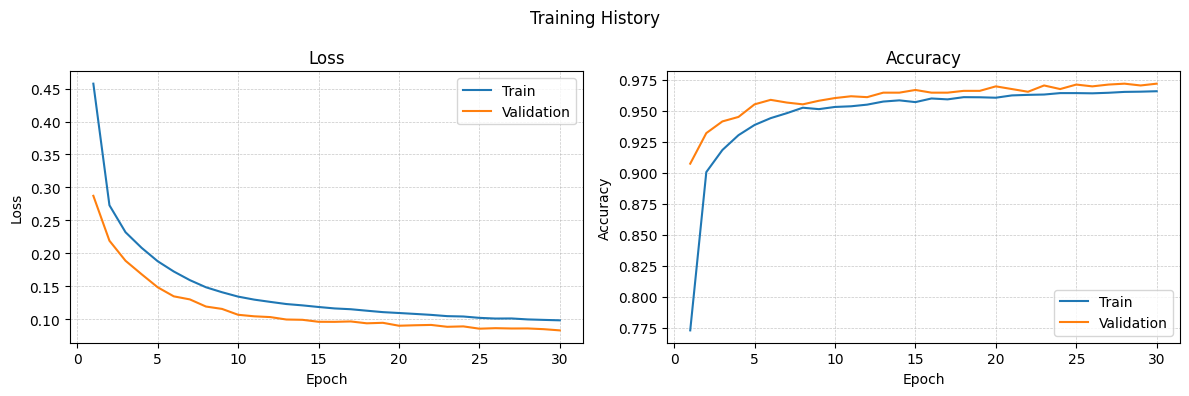

In [41]:
from building_tensorflow.utils import plot_training_history
plot_training_history(history)

352it [00:20, 17.83it/s]2026-04-10 11:10:04.037777: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
353it [00:20, 17.56it/s]
44it [00:02, 20.98it/s]2026-04-10 11:10:06.688191: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
44it [00:02, 18.77it/s]


=== Binary classifier metrics : TEST SET===
Threshold: 0.2617  (best F2 threshold)
Accuracy : 0.9569
Precision: 0.8902
Recall   : 0.9913
F2 score : 0.9693
=== Binary classifier metrics : TRAIN SET===
AUC      : 0.9936


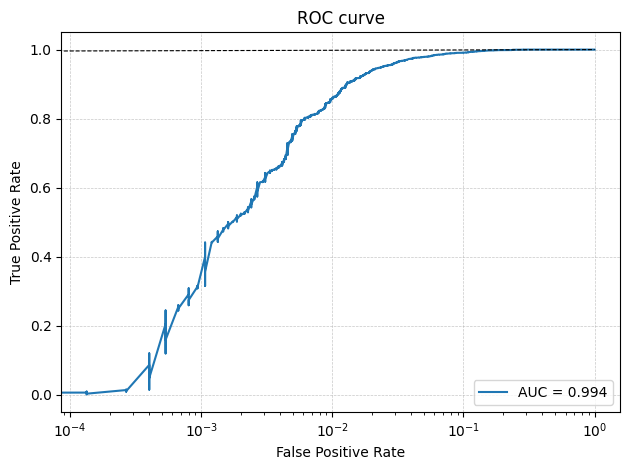

In [ ]:
from building_tensorflow.utils import evaluate_binary_classifier, display_eval_metrics
train_metrics, test_metrics = evaluate_binary_classifier(training_model,
 train_ds,
 test_ds,
  threshold=0.5,)
display_eval_metrics(train_metrics, test_metrics)

## Make frontend filters into a Conv1D inference model


In [43]:
# Extract the trained custom frontend and bake its filters
custom_layer = None
for layer in training_model.layers:
    if isinstance(layer, CustomFrontend):
        custom_layer = layer
        break

if custom_layer is None:
    raise RuntimeError("CustomFrontend layer not found in training_model")

baked_filters = custom_layer.get_filters().numpy()

# Build Conv1D-based inference model
infer_inputs = keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))
x = keras.layers.Conv1D(
    filters=NUM_FILTERS,
    kernel_size=KERNEL_SIZE,
    strides=STRIDE,
    padding="valid",
    use_bias=False,
    name="baked_conv",
)(infer_inputs)
x = keras.layers.GlobalAveragePooling1D()(x)
x = keras.layers.Dense(64, activation="relu", name="dense_hidden")(x)
infer_outputs = keras.layers.Dense(num_labels, activation=None, name="dense_logits")(x)

inference_model = keras.Model(infer_inputs, infer_outputs, name="sincnet_time_inference")

# Copy weights
inference_model.get_layer("baked_conv").set_weights([baked_filters])
inference_model.get_layer("dense_hidden").set_weights(
    training_model.layers[-2].get_weights()
)
inference_model.get_layer("dense_logits").set_weights(
    training_model.layers[-1].get_weights()
)

# Optional parity check on a small batch
for batch_audio, _ in test_ds.take(1):
    batch_audio_np = batch_audio.numpy()
    logits_train = training_model.predict(batch_audio_np, verbose=0)
    logits_infer = inference_model.predict(batch_audio_np, verbose=0)
    print("Max abs diff between training and inference logits:", np.max(np.abs(logits_train - logits_infer)))

Max abs diff between training and inference logits: 72.05328


2026-04-10 11:08:21.763722: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Export quantized TFLite model and Rust audio samples

We now export an int8-quantized TFLite model using the shared helpers from `building_tensorflow.utils`, and regenerate `audio_sample.rs` clips for the TinyChirp Rust runner.

In [44]:
# Build representative batches for post-training quantization
rep_batches = build_representative_batches(
    test_ds,
    target_len=TARGET_AUDIO_LEN_TIME,
    take=100,
)

# Export int8 TFLite model
try:
    export_keras_model_to_int8_tflite(inference_model, rep_batches, OUT_TFLITE)
    print(f"Success! Wrote {OUT_TFLITE}")
except Exception as e:
    print(f"TFLite conversion failed: {e}")

# Collect test clips and write Rust audio_sample.rs
clips = collect_test_clips_for_rs(
    DATASET_ROOT / "testing",
    sample_rate=SAMPLE_RATE,
    target_len=TARGET_AUDIO_LEN_TIME,
    num_per_label=2,
)

write_audio_sample_rs(
    OUT_AUDIO_RS,
    clips,
    SAMPLE_RATE,
    generator_name="building_tensorflow/sincnet_time.ipynb",
)

print(
    "Wrote",
    OUT_AUDIO_RS,
    "clips=",
    len(clips),
    "samples_per_clip=",
    len(clips[0][1]),
)

INFO:tensorflow:Assets written to: temp_saved_model/assets


2026-04-10 11:08:22.079918: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
INFO:tensorflow:Assets written to: temp_saved_model/assets


Saved artifact at 'temp_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 47872, 1), dtype=tf.float32, name='keras_tensor_63')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  133762943627184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133755875072256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133755875077184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133755875072080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133755875077536: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1775812102.245426   20360 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1775812102.245696   20360 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-04-10 11:08:22.246507: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: temp_saved_model
2026-04-10 11:08:22.246895: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-10 11:08:22.246907: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: temp_saved_model
2026-04-10 11:08:22.251767: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-04-10 11:08:22.269571: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: temp_saved_model
2026-04-10 11:08:22.275099: I tensorflow/cc/saved_model/loader.cc:317] SavedModel load for tags { serve }; Status: success: OK. Took 28596 microseconds.


Success! Wrote /home/nathan/Documents/tiny-chirp-microflow/models/sincnet_time_tf.tflite
Found 1393 files belonging to 2 classes.


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


Wrote /home/nathan/Documents/tiny-chirp-microflow/src/audio_sample.rs clips= 4 samples_per_clip= 47872
